In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('Pharma_Industry.csv')

### Exploratory Data Analysis(EDA)

#### 1. Fundamental data exploration.

In [3]:
data.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [5]:
data.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [6]:
data.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


#### 2. Visualization

#### Hstogram with Density plot

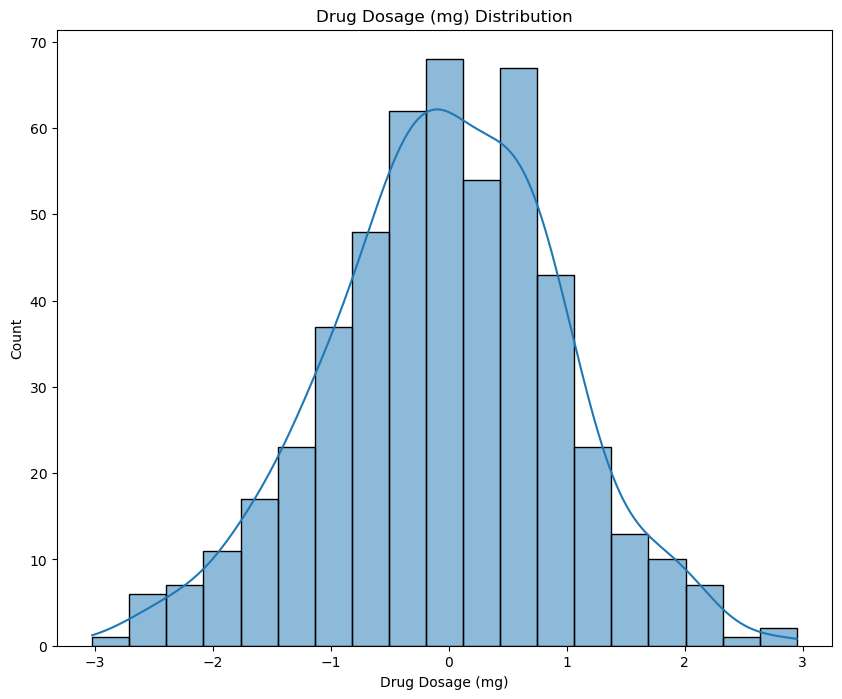

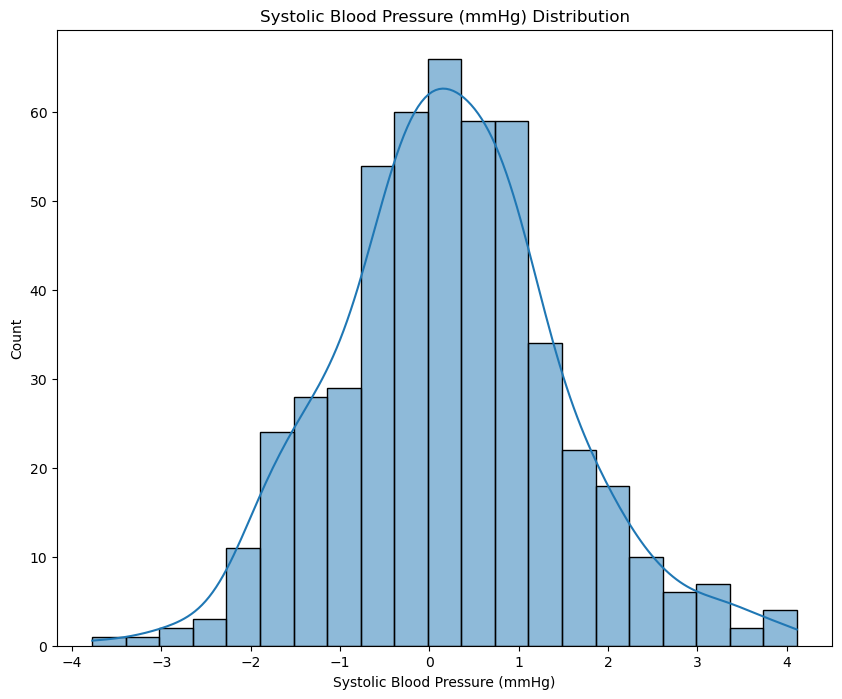

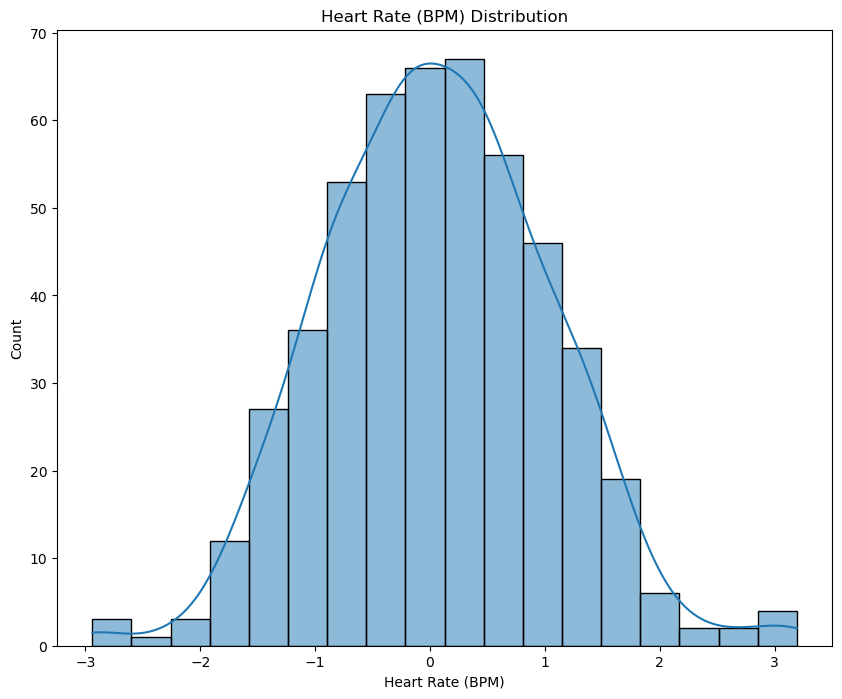

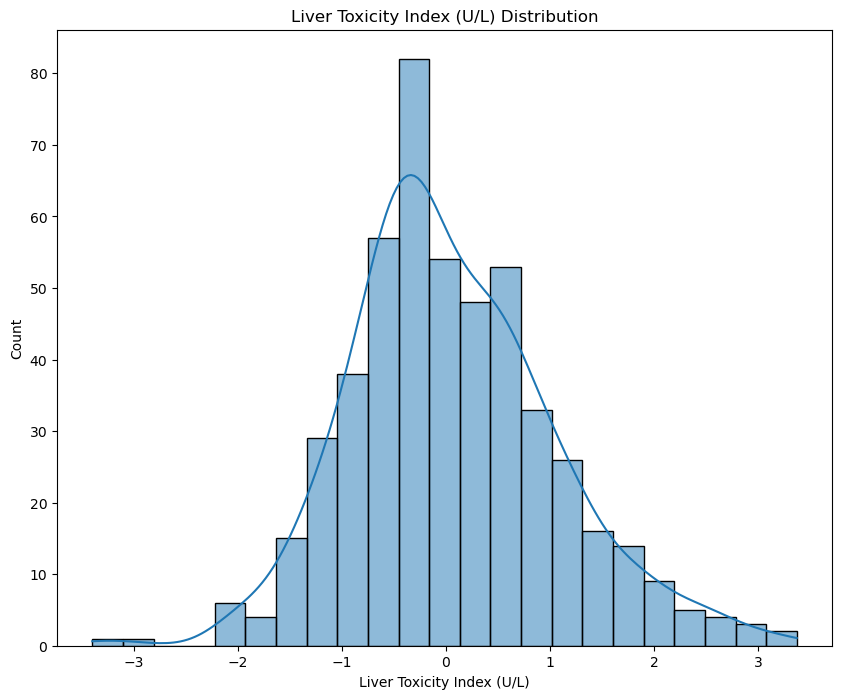

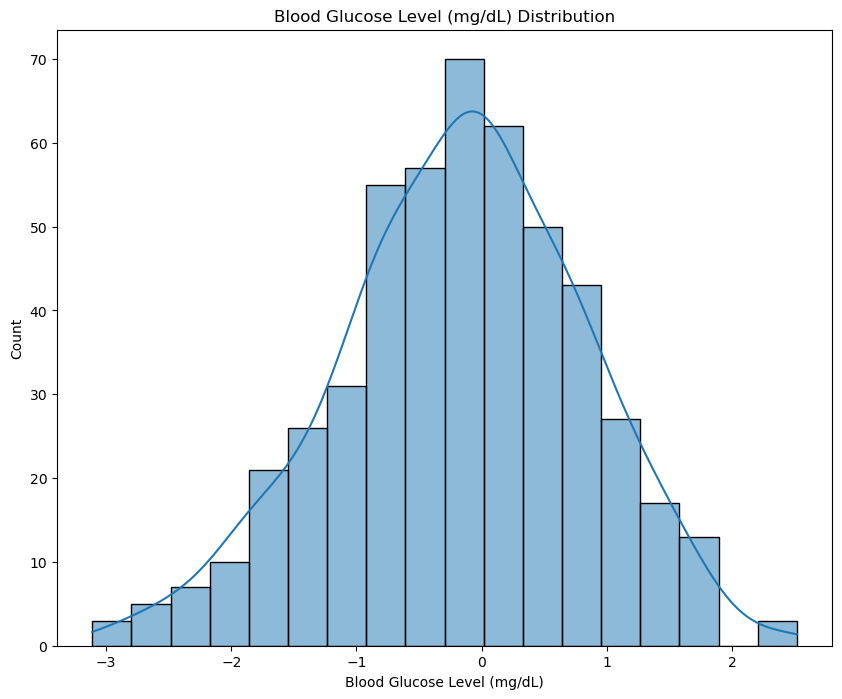

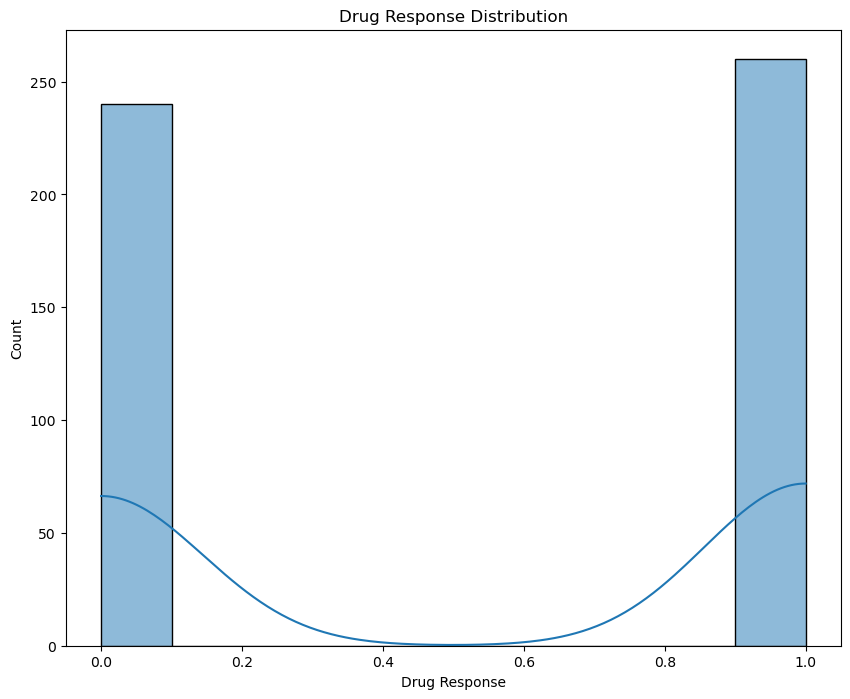

In [7]:
for col in data:
    plt.figure(figsize=(10,8))
    sns.histplot(data[col],kde=True)
    plt.title(f'{col} Distribution')
    plt.show()

#### Boxplot

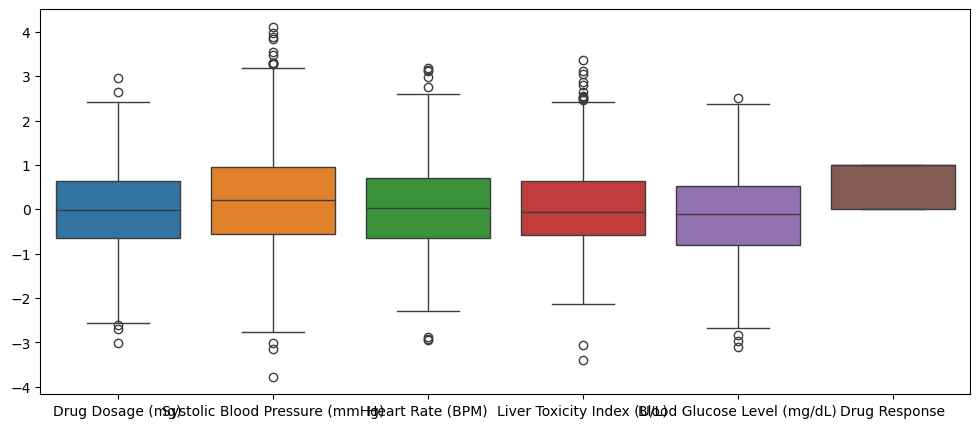

In [8]:
plt.figure(figsize=(12,5))
sns.boxplot(data)
plt.show()

#### Outliers Are present according to Boxplot, But everytime not necessory to rremove outliers

#### we are using SVM. 

#### SVM is less sensitive to outliers compared to models like Linear Regression

##### i. SVM focuses on support vectors (boundary points)
##### ii. Not all data points affect the model equally

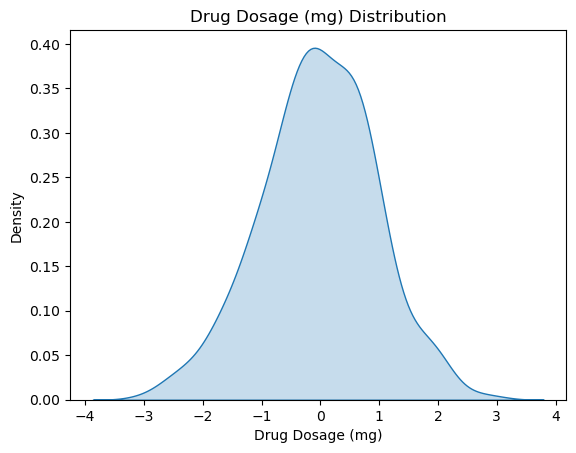

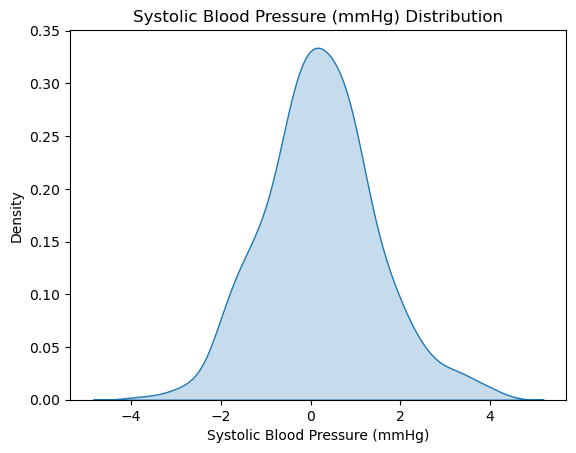

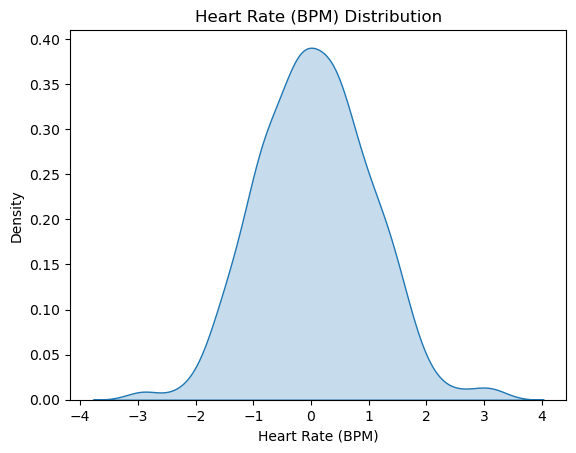

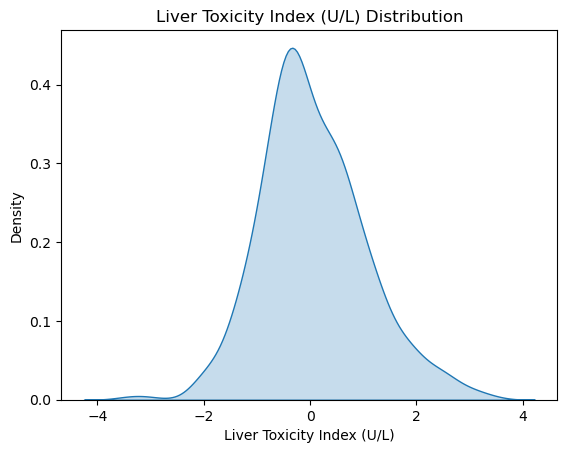

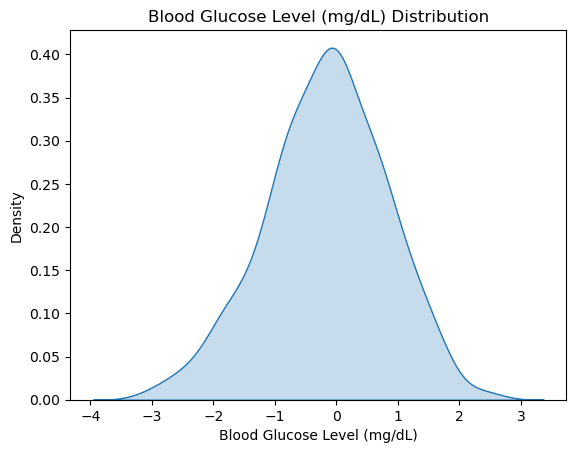

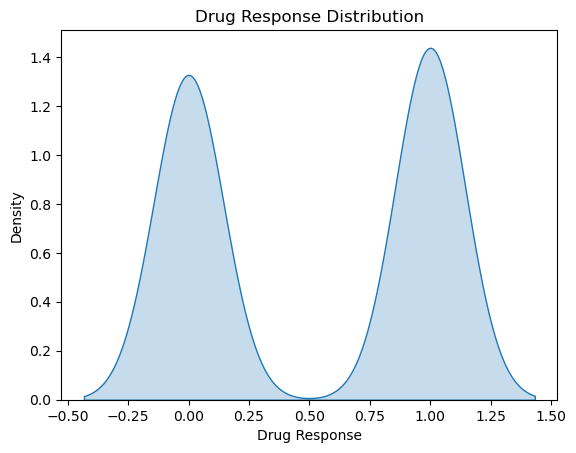

In [9]:
for col in data:
    sns.kdeplot(data[col],fill=True)
    plt.title(f'{col} Distribution')
    plt.show()

#### Correlation Heatmap

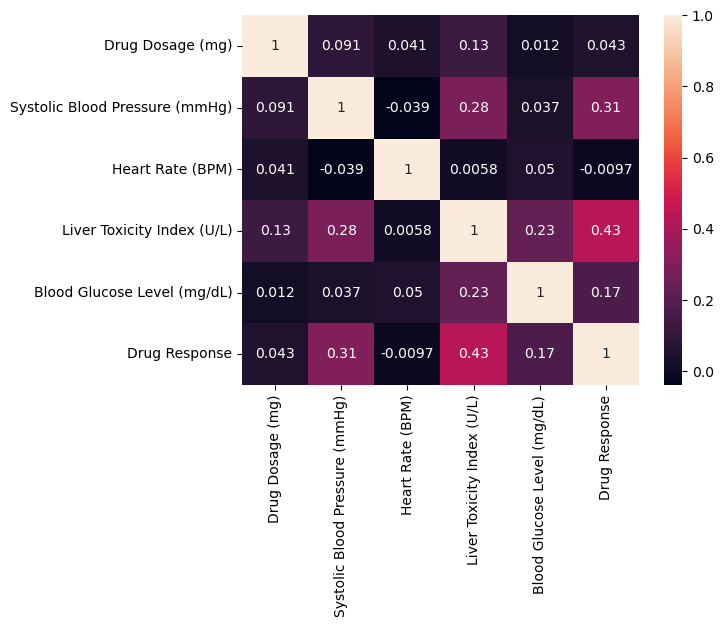

In [11]:
corr = data.corr()
sns.heatmap(corr, annot = True)
plt.show()

#### This indicates that the dataset may have non-linear relationships, which justifies the use of SVM with non-linear kernels like RBF.

### Data Preprocessing :

In [14]:
from sklearn.model_selection import train_test_split

X = data.drop("Drug Response", axis=1)
y = data["Drug Response"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((400, 5), (100, 5), (400,), (100,))

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Data Visualization

#### Pairplot

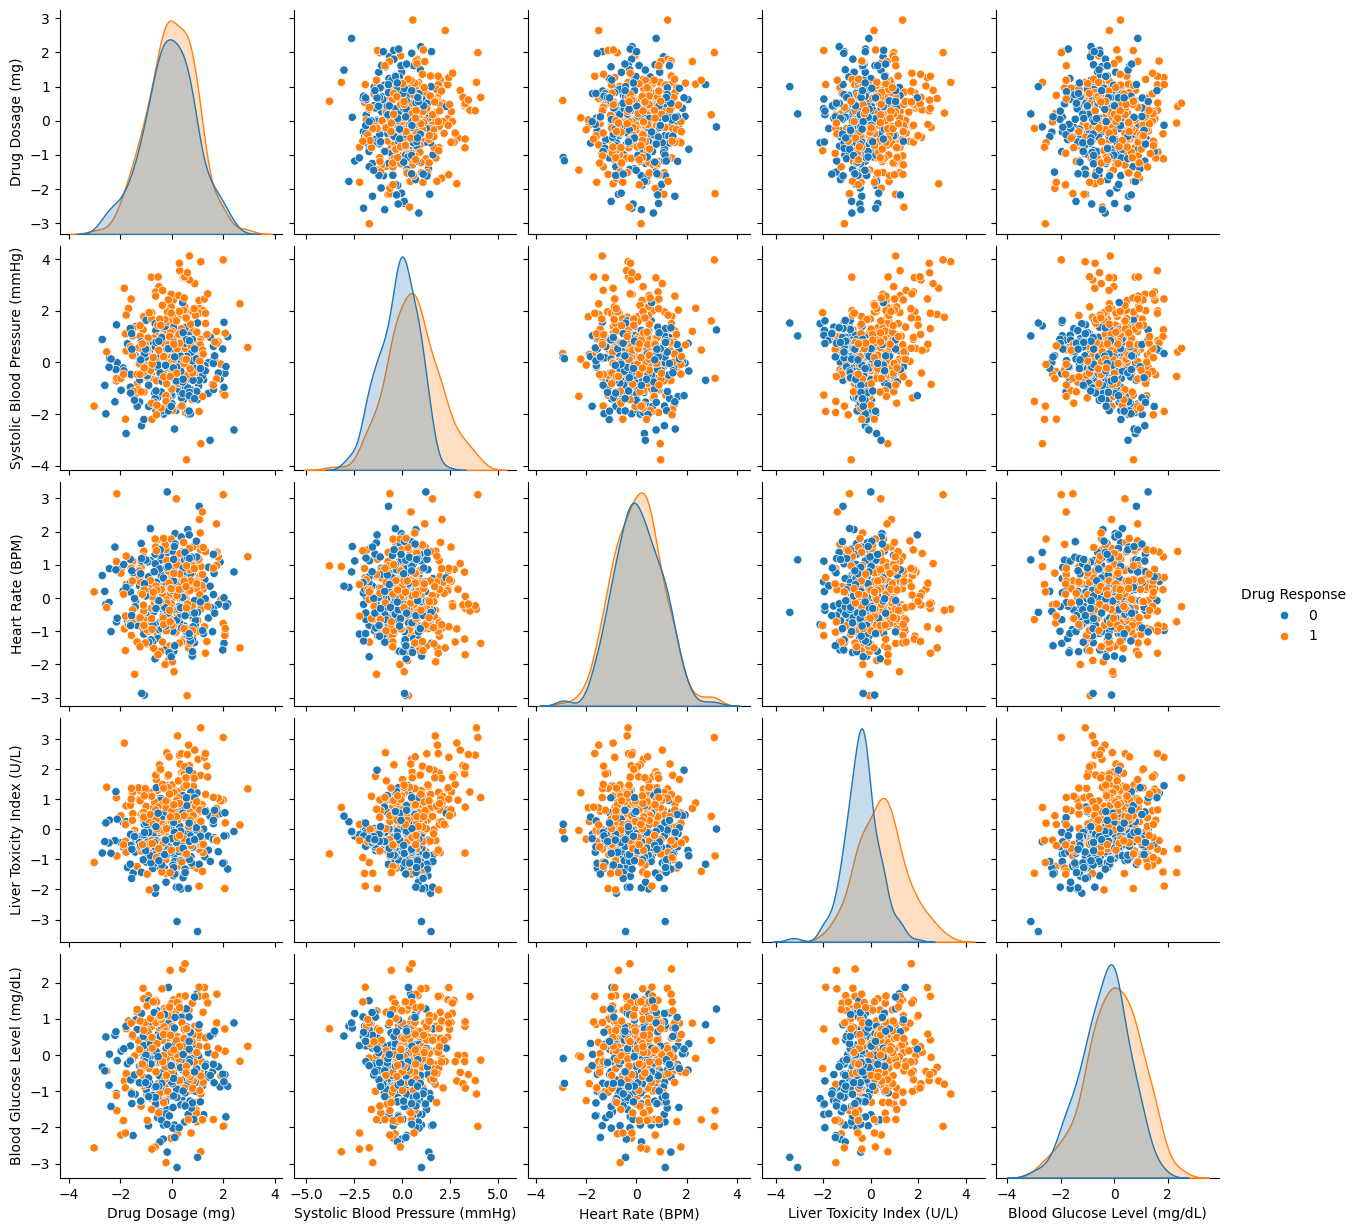

In [19]:
sns.pairplot(data,hue='Drug Response')
plt.show()

#### The dataset is not linearly separable

#### Countplot

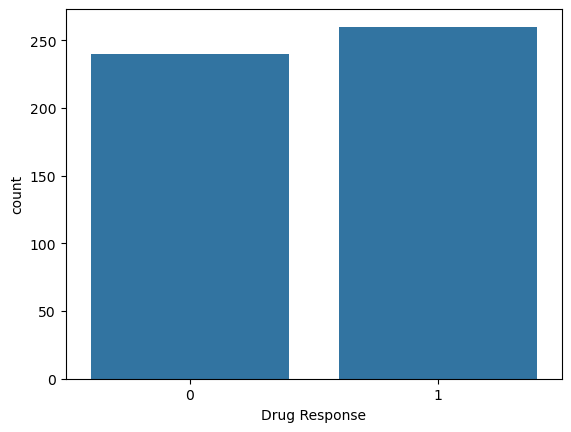

In [21]:
sns.countplot(x='Drug Response',data=data)
plt.show()

### SVM Implementation :

In [24]:
from sklearn.svm import SVC

model = SVC(kernel='linear')

model.fit(X_train, y_train)

SVC(kernel='linear')

In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.78
              precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100



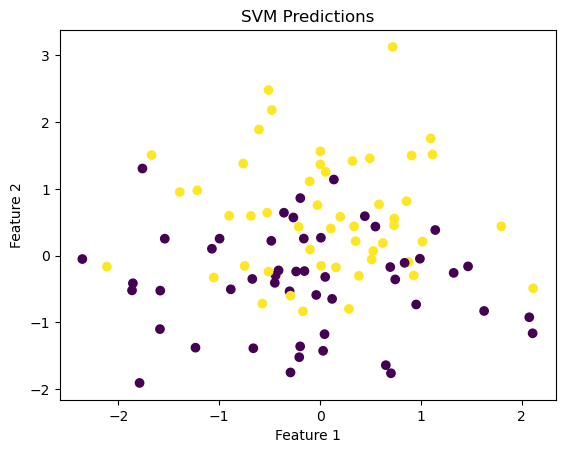

In [31]:
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred)
plt.title("SVM Predictions")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [28]:
model = SVC(kernel='rbf', C=1, gamma='scale')
model.fit(X_train, y_train)

SVC(C=1)

In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [32]:
print("Best Score:", grid.best_score_)

Best Score: 0.7300000000000001


In [34]:
best_model = grid.best_estimator_
best_model

SVC(C=1)

### Comparison & Analysis :

#### 1. Kernel Comparison :

| Kernel     | Accuracy | Observation                    |
| ---------- | -------- | ------------------------------ |
| Linear     | 78%      | Works well for simple patterns |
| RBF        | 85%      | Best performance               |
| Polynomial | 80%      | Slightly better but slower     |


#### 2. Analysis Based on EDA :

##### Most correlation values are low to moderate, No feature shows very high correlation (> 0.7)

##### Data points of both classes (0 and 1) are heavily overlapping, No clear straight-line separation between classes

##### It shows a bimodal distribution, meaning the target has two classes (0 and 1), so it is a binary classification problem with balanced classes.

#### 3. Strengths & Weaknesses :

#### Strengths of SVM
##### i. Works well for high-dimensional data
##### ii. Effective when clear margin of separation exists
##### iii. Kernel trick helps handle non-linear data

#### Weaknesses
##### i. Requires feature scaling (you applied StandardScaler)
##### ii. Not suitable for very large datasets
##### iii. Choosing correct kernel is trial-and-error

#### 4. Practical Implications :

#### Real-world Use :
##### i. In medical datasets (like drug response):
##### ii. SVM can help predict whether a patient will respond to a drug
##### iii. Helps doctors in decision making

#### General Applications
##### i. Disease prediction
##### ii. Spam email classification
##### iii. Image recognition

### Conclusion :

#### - In this project, SVM models with different kernels were implemented and compared. 
#### - Among them, the RBF kernel achieved the best performance due to its ability to capture non-linear relationships in the dataset.
#### - Hyperparameter tuning using GridSearchCV significantly improved model accuracy.
#### - This demonstrates that SVM is a powerful classification technique, especially for complex datasets like drug response prediction.